In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split



In [ ]:
# %pip install tensorflow

#we need model and layer
from tensorflow.keras.models import Sequential #(ip)
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
# (op)
#import layer



In [ ]:
from PIL import Image #pillow


In [ ]:
import os
currdir=os.getcwd()
os.listdir(os.getcwd())
print("total cats " ,len(os.listdir(os.path.join(currdir,"images","cats"))) )
print("total dogs " ,len(os.listdir(os.path.join(currdir,"images","dogs"))) )

# this data is not in dataset form (k:V)
#create dict to hold it
# cats = {}
# dogs = {}

#curent img path

imgpath=os.path.join(currdir,"images")

os.listdir(imgpath) #give cat and dog folder as output

#create for loop to put into this 

In [ ]:
pathdict={'cats':[],'dogs':[]}
for dir in os.listdir(imgpath):
    dirpath=os.path.join(imgpath,dir)
    for images in os.listdir(dirpath):
        pathdict[dir].append(os.path.join(dirpath,images))

print(pathdict.keys())
# print(pathdict.values())
# print(pathdict["dogs"][1])
print(pathdict["dogs"][1])
print(pathdict.keys())
print(pathdict.values())
        

In [ ]:
from PIL import Image
Image.open(pathdict['cats'][4])

In [ ]:
# now this img is ready to be encoded
#encoding the img to vector 

#reading each img and encode it 

import cv2

In [ ]:
print(pathdict.items())
#key : values

img_arr_lst=[] #have img 
labels=[] ##cat dog

for key , value in pathdict.items():
    # key : have key cat or dog
    for path in value:
        #encoding
        # 2 list to have dependent and undependent 
        img_arr=cv2.imread(path) #read nd encode it 

        #to train any img , size of img should  be same 
        # function called cv2.resize

        resize_img_arr=cv2.resize(img_arr,(224,244))
        img_arr_lst.append(resize_img_arr)
        labels.append(key)

print(img_arr_lst) #img converted to array
print(labels)

#assign cat dog encoding
# for label in labels:
    
img_arr_lst=np.array(img_arr_lst)
labels=np.array(labels)

        


In [ ]:
labels=np.array([1 if item =="cats" else 0 for item in labels]) #list concurencer

In [ ]:
labels

In [ ]:
# splitting of 

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test =train_test_split(img_arr_lst,labels,test_size=0.2,random_state=42)



In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape


In [ ]:
#conver it into pixels 0-255

#to find value in pixel , we convert x_train(indep)/255 in pixel
#x_test also into pixels and reput

x_train=x_train/255
x_test=x_test/255


In [ ]:
# layer 1 : conventional layer

model=Sequential(
    [
        Conv2D(64,(3,3),activation='relu',input_shape=(244,224,3)), #x_train.shape in input
        MaxPooling2D(2,2),
        
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(16,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(64,activation='relu'),
        Dense(1,activation='sigmoid')
    ]
)

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])




In [ ]:
print(x_train.shape)

history=model.fit(x_train, y_train, epochs=10, batch_size=32)

In [ ]:
# Read and preprocess the image for prediction

# Predict on test set and single image
pred = model.predict(x_test)
# print(pred.score)

# print(pred)
# print("Single image prediction:", pred)
model.save("model.keras")


d:\aimltraining\dl\CNN\Cat_Dog_classification\test\dog2.webp


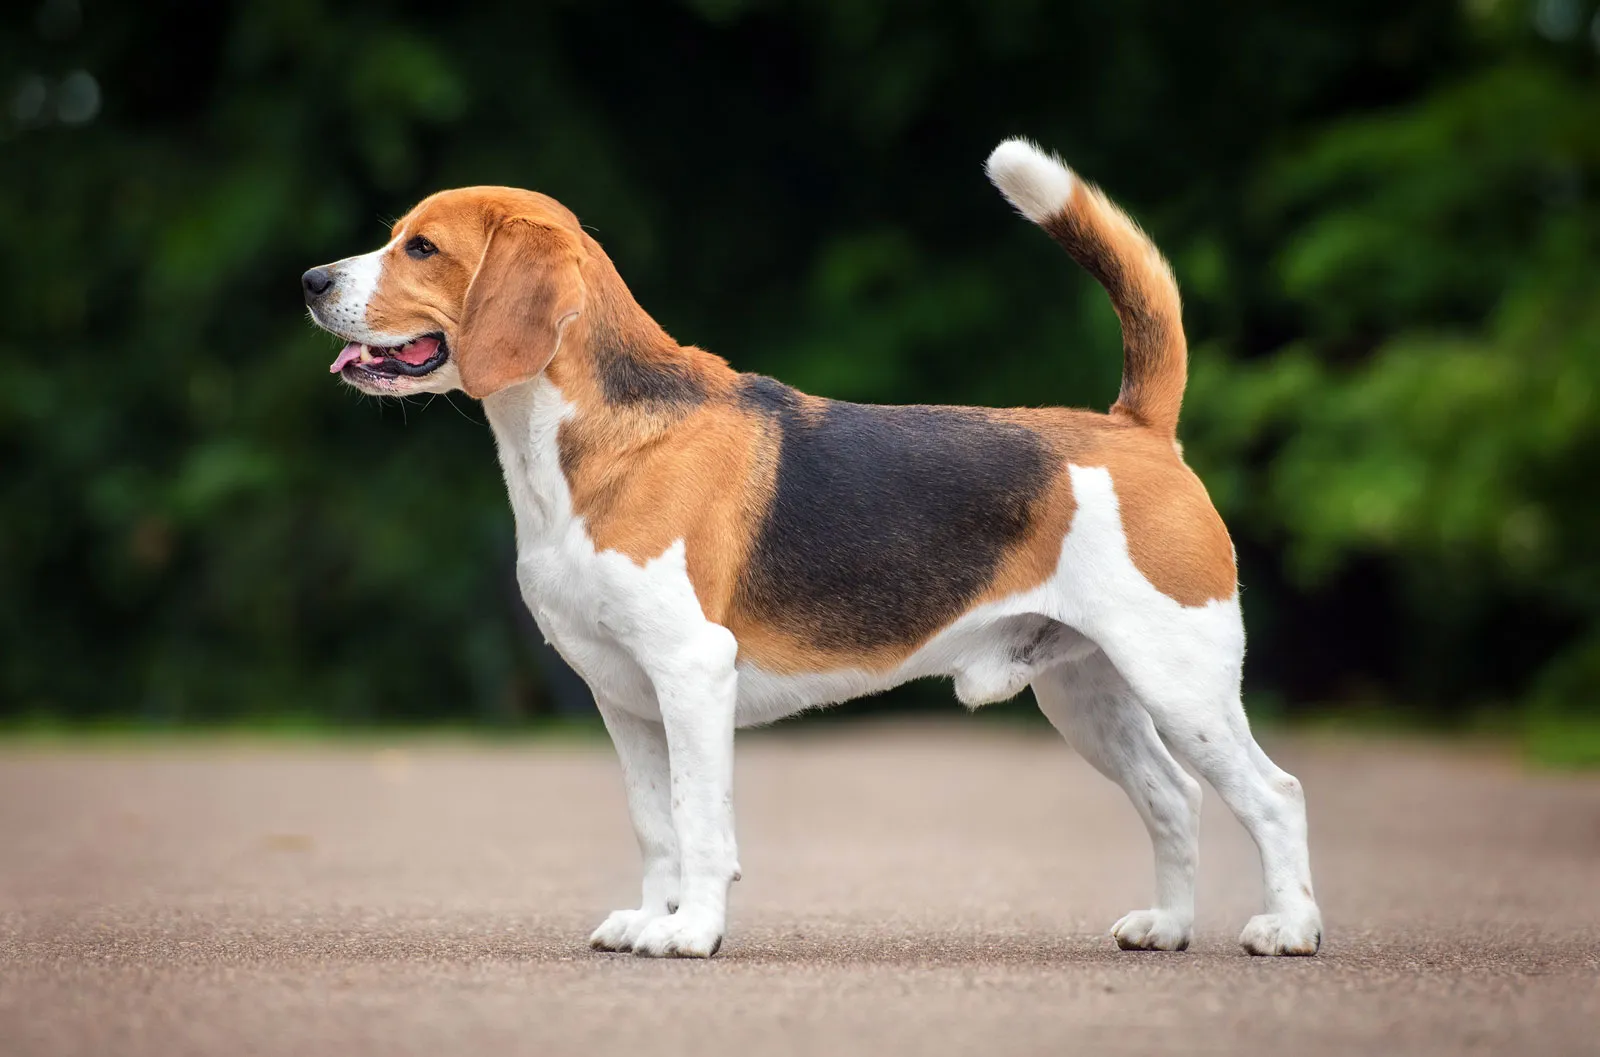

In [68]:
#testing a img using this model
# import cv2
import os

# Get current directory
currdir = os.getcwd()

# Path to the 'test' folder
test_folder = os.path.join(currdir, "test")

# List all files in the 'test' folder
files = os.listdir(test_folder)

# Get the full path of the first image
# imgpath = os.path.join(test_folder, files[0])
# imgpath2 = os.path.join(test_folder, files[1])
imgpath3 = os.path.join(test_folder, files[2])
# imgpath4= os.path.join(test_folder, files[3])


# print( imgpath)
# print(imgpath2)
print(imgpath3)
#encoding data



import cv2

# testimg=cv2.imread(imgpath)
# testimg2=cv2.imread(imgpath2)
testimg3=cv2.imread(imgpath3)
# print(img_Arr)

# resize_img_arr
# resize_testimg=cv2.resize(testimg,(224,244))
# resize_testimg2=cv2.resize(testimg2,(224,244))
resize_testimg3=cv2.resize(testimg3,(224,244))
# resize_testimg=resize_testimg/255
# resize_testimg2=resize_testimg2/255
resize_testimg3=resize_testimg3/255
# resize_testimg = np.expand_dims(resize_testimg, axis=0) 
# resize_testimg2 = np.expand_dims(resize_testimg2, axis=0) 
resize_testimg3 = np.expand_dims(resize_testimg3, axis=0) 

from PIL import Image
# Image.open(imgpath2)
Image.open(imgpath3)


In [70]:
from tensorflow.keras.models import load_model

loadedmodel=load_model("model.keras")
# pref=loadedmodel.predict(resize_testimg)
# pref2=loadedmodel.predict(resize_testimg2)
pref3=loadedmodel.predict(resize_testimg3)

# print(pref2 , " ", imgpath2)
print(pref3 , " ", imgpath3)
print("\n" + "="*50)
print("PREDICTION RESULTS")
print("="*50)
print(f"Raw prediction value: {pref3[0][0]:.4f}")
print(f"Prediction probability: {pref3[0][0]*100:.2f}%")

threshold = 0.5
margin = 0.05  # 5% uncertainty zone

prob = pref3[0][0]

if prob > threshold + margin:
    print(f"🐱 CAT (Confidence: {prob*100:.2f}%)")
    print("Cat")
elif prob < threshold - margin:
    print(f"🐶 DOG (Confidence: {(1-prob)*100:.2f}%)")
    print("dog")
else:
    print(f"🤔 UNCERTAIN (CAT:{prob*100:.2f}%, DOG:{(1-prob)*100:.2f}%)")
    print(f"🤔 UNCERTAIN (CAT:{prob*100:.2f}%, DOG:{(1-prob)*100:.2f}%)")
    print(f"🤔 UNCERTAIN (CAT:{prob*100:.2f}%, DOG:{(1-prob)*100:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step

d:\aimltraining\dl\CNN\Cat_Dog_classification\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
[[0.00052372]]   d:\aimltraining\dl\CNN\Cat_Dog_classification\test\dog2.webp

PREDICTION RESULTS
Raw prediction value: 0.0005
Prediction probability: 0.05%
🐶 DOG (Confidence: 99.95%)
dog
